<a href="https://colab.research.google.com/github/p3nny-lan3/DATA-201_Rin-Hwang/blob/main/Week2_Python_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Python Assignment
## Rin Hwang

### Question 8

In [73]:
import pandas as pd
import numpy as np

In [74]:
# (a)

college = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/refs/heads/main/Dataset/College.csv")


In [75]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [76]:
# (b)

college2 = pd.read_csv('https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/refs/heads/main/Dataset/College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'},
                          axis=1)
#college = college3_sex_index('College')
college = college3

In [77]:
# (c)

college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

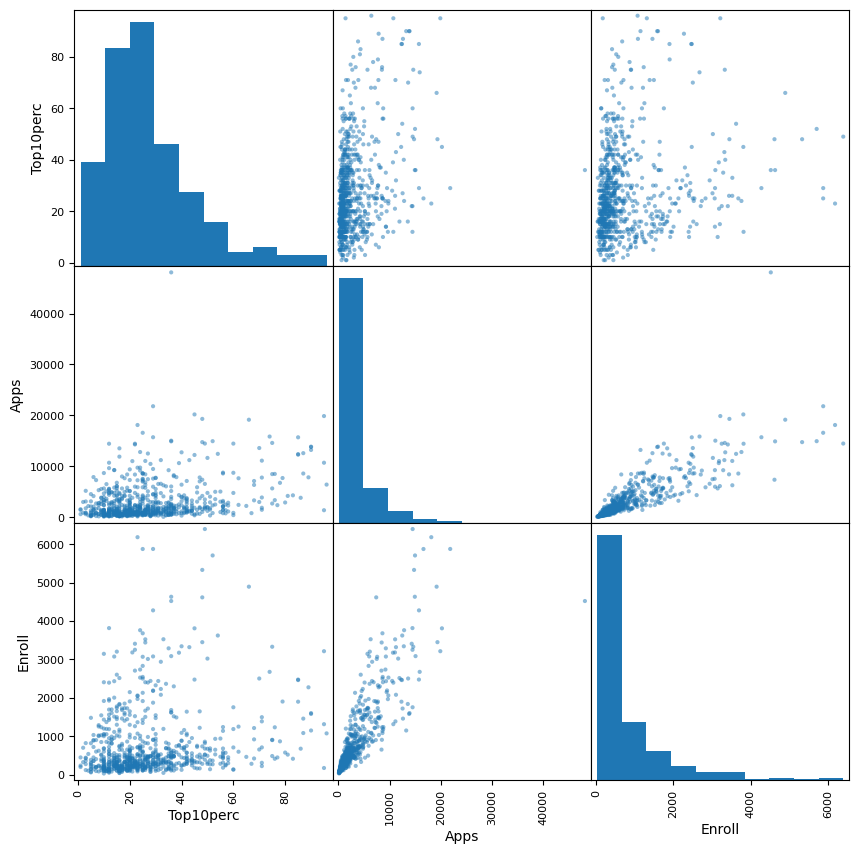

In [78]:
# (d)

pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']], figsize=(10, 10))

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

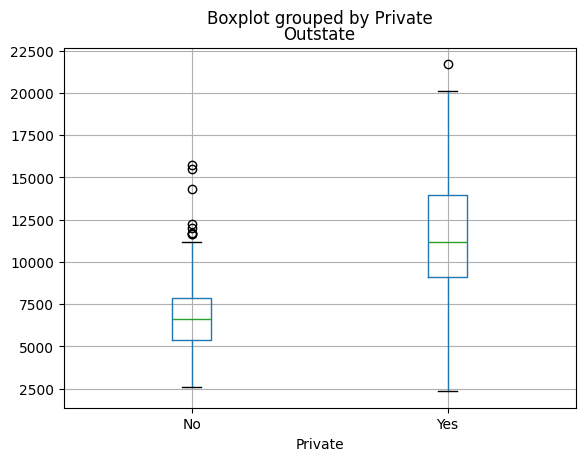

In [79]:
# (e)

college.boxplot(column='Outstate', by='Private')

Elite
No     699
Yes     78
Name: count, dtype: int64


<Axes: title={'center': 'Outstate'}, xlabel='Elite'>

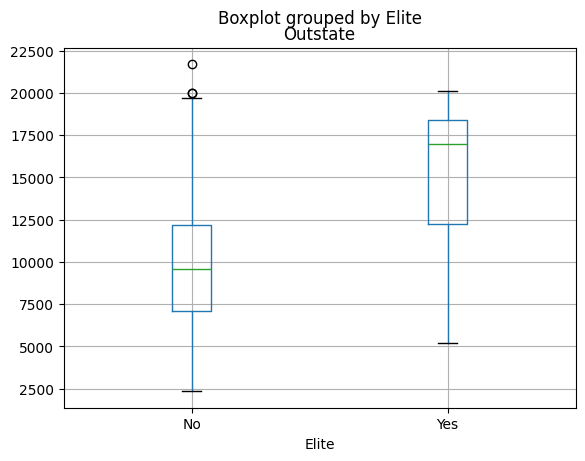

In [80]:
# (f)

college['Elite'] = pd.cut(college['Top10perc'],
                          [0,0.5,1],
                          labels = ['No', 'Yes'])
college['Elite'] = pd.Series('No', index=college.index)
college.loc[college['Top10perc'] > 50, 'Elite'] = 'Yes'

print(college['Elite'].value_counts())

college.boxplot(column='Outstate', by='Elite')

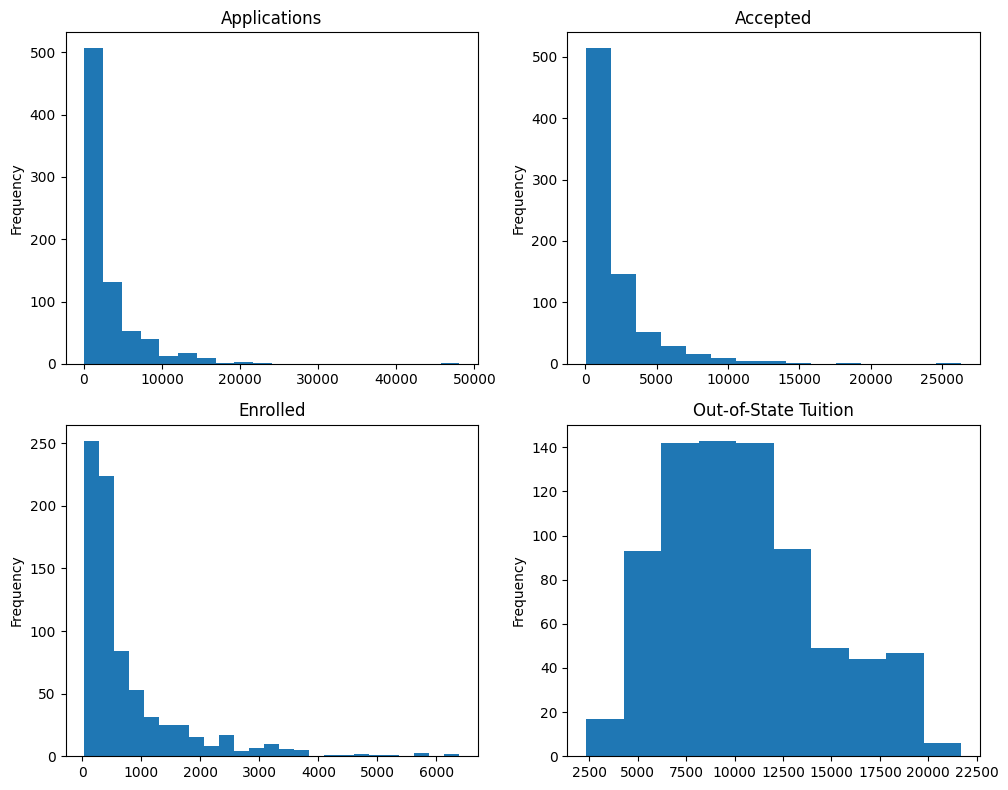

In [81]:
# (g)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

college['Apps'].plot.hist(ax=axes[0, 0], bins=20, title='Applications')
college['Accept'].plot.hist(ax=axes[0, 1], bins=15, title='Accepted')
college['Enroll'].plot.hist(ax=axes[1, 0], bins=25, title='Enrolled')
college['Outstate'].plot.hist(ax=axes[1, 1], bins=10, title='Out-of-State Tuition')

plt.tight_layout()
plt.show()

(h)

Based on these visualizations, elite institutions generally have higher median out-of-state tuition compared to non-elite institutions, with some non-elite outliers at the higher price range. "Outstate" is fairly symmetric and shows a roughly normal distribution compared to admission metrics. Variables like "Apps", "Accept", and "Enroll" are heavily right-skewed so we can see that most institutions have relatively small applicant pools and class sizes, while a small handful of large universities receive disproportionately massive application volumes.

### Question 9

In [82]:
auto = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/refs/heads/main/Dataset/Auto.csv", na_values=['?'])

auto["horsepower"] = auto["horsepower"].replace("?", pd.NA)
auto["horsepower"] = pd.to_numeric(auto["horsepower"])

In [83]:
print(auto)

      mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0    18.0          8         307.0       130.0    3504          12.0    70   
1    15.0          8         350.0       165.0    3693          11.5    70   
2    18.0          8         318.0       150.0    3436          11.0    70   
3    16.0          8         304.0       150.0    3433          12.0    70   
4    17.0          8         302.0       140.0    3449          10.5    70   
..    ...        ...           ...         ...     ...           ...   ...   
392  27.0          4         140.0        86.0    2790          15.6    82   
393  44.0          4          97.0        52.0    2130          24.6    82   
394  32.0          4         135.0        84.0    2295          11.6    82   
395  28.0          4         120.0        79.0    2625          18.6    82   
396  31.0          4         119.0        82.0    2720          19.4    82   

     origin                       name  
0         1  chevrolet

In [84]:
# (a)
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.0+ KB


Quantitative: "mpg", "cylinders", "displacement", "horsepower", "weight", and "acceleration"

Qualitative: "year", "origin","name"

In [85]:
# (b)

print(auto.min())
auto.max()

mpg                                 9.0
cylinders                             3
displacement                       68.0
horsepower                         46.0
weight                             1613
acceleration                        8.0
year                                 70
origin                                1
name            amc ambassador brougham
dtype: object


,0
mpg,46.6
cylinders,8
displacement,455.0
horsepower,230.0
weight,5140
acceleration,24.8
year,82
origin,3
name,vw rabbit custom


**Ranges of the quantitative predictors**

"mpg": 37.6  
"cylinders": 5  
"displacement": 387.0  
"horsepower": 184.0  
"weight": 3527  
"acceleration": 16.8

In [86]:
# (c)

auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,392.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,104.469388,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,38.491160,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,75.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,93.500000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Means**  

"mpg": 23.515869  
"cylinders": 5.458438  
"displacement": 193.532746  
"horsepower": 104.469388  
"weight": 2970.261965	  
"acceleration": 15.555668  

**Standard Deviation**  

"mpg": 7.825804  
"cylinders": 1.701577  
"displacement": 104.379583  
"horsepower": 38.491160  
"weight": 847.904119		  
"acceleration": 2.749995

In [87]:
# (d)

auto_subset = auto.drop(auto.index[9:85])

print("Original rows:", len(auto))
print("New rows:", len(auto_subset))
print("Difference:", len(auto) - len(auto_subset))

Original rows: 397
New rows: 321
Difference: 76


In [88]:
auto_subset.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,321.000000,321.000000,321.000000,317.000000,321.000000,321.000000,321.000000,321.000000
mean,24.438629,5.370717,187.049844,100.955836,2933.962617,15.723053,77.152648,1.598131
std,7.908184,1.653486,99.635385,35.895567,810.642938,2.680514,3.111230,0.816163
min,11.000000,3.000000,68.000000,46.000000,1649.000000,8.500000,70.000000,1.000000
25%,18.000000,4.000000,100.000000,75.000000,2215.000000,14.000000,75.000000,1.000000
50%,23.900000,4.000000,145.000000,90.000000,2795.000000,15.500000,77.000000,1.000000
75%,30.700000,6.000000,250.000000,115.000000,3504.000000,17.300000,80.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,24.800000,82.000000,3.000000


With rows removed  

**Range**    

"mpg": 35.6  
"cylinders": 5  
"displacement": 387.0  
"horsepower": 184.0  
"weight": 3348	  
"acceleration": 16.3  

**Means**  

"mpg": 28.055030  
"cylinders": 5.370717  
"displacement": 187.049844  
"horsepower": 100.955836  
"weight": 2933.962617  
"acceleration": 15.723053  

**Standard Deviation**  

"mpg": 7.908184  
"cylinders": 1.653486  
"displacement": 99.635385  
"horsepower": 35.895567  
"weight": 810.642938		  
"acceleration": 2.680514

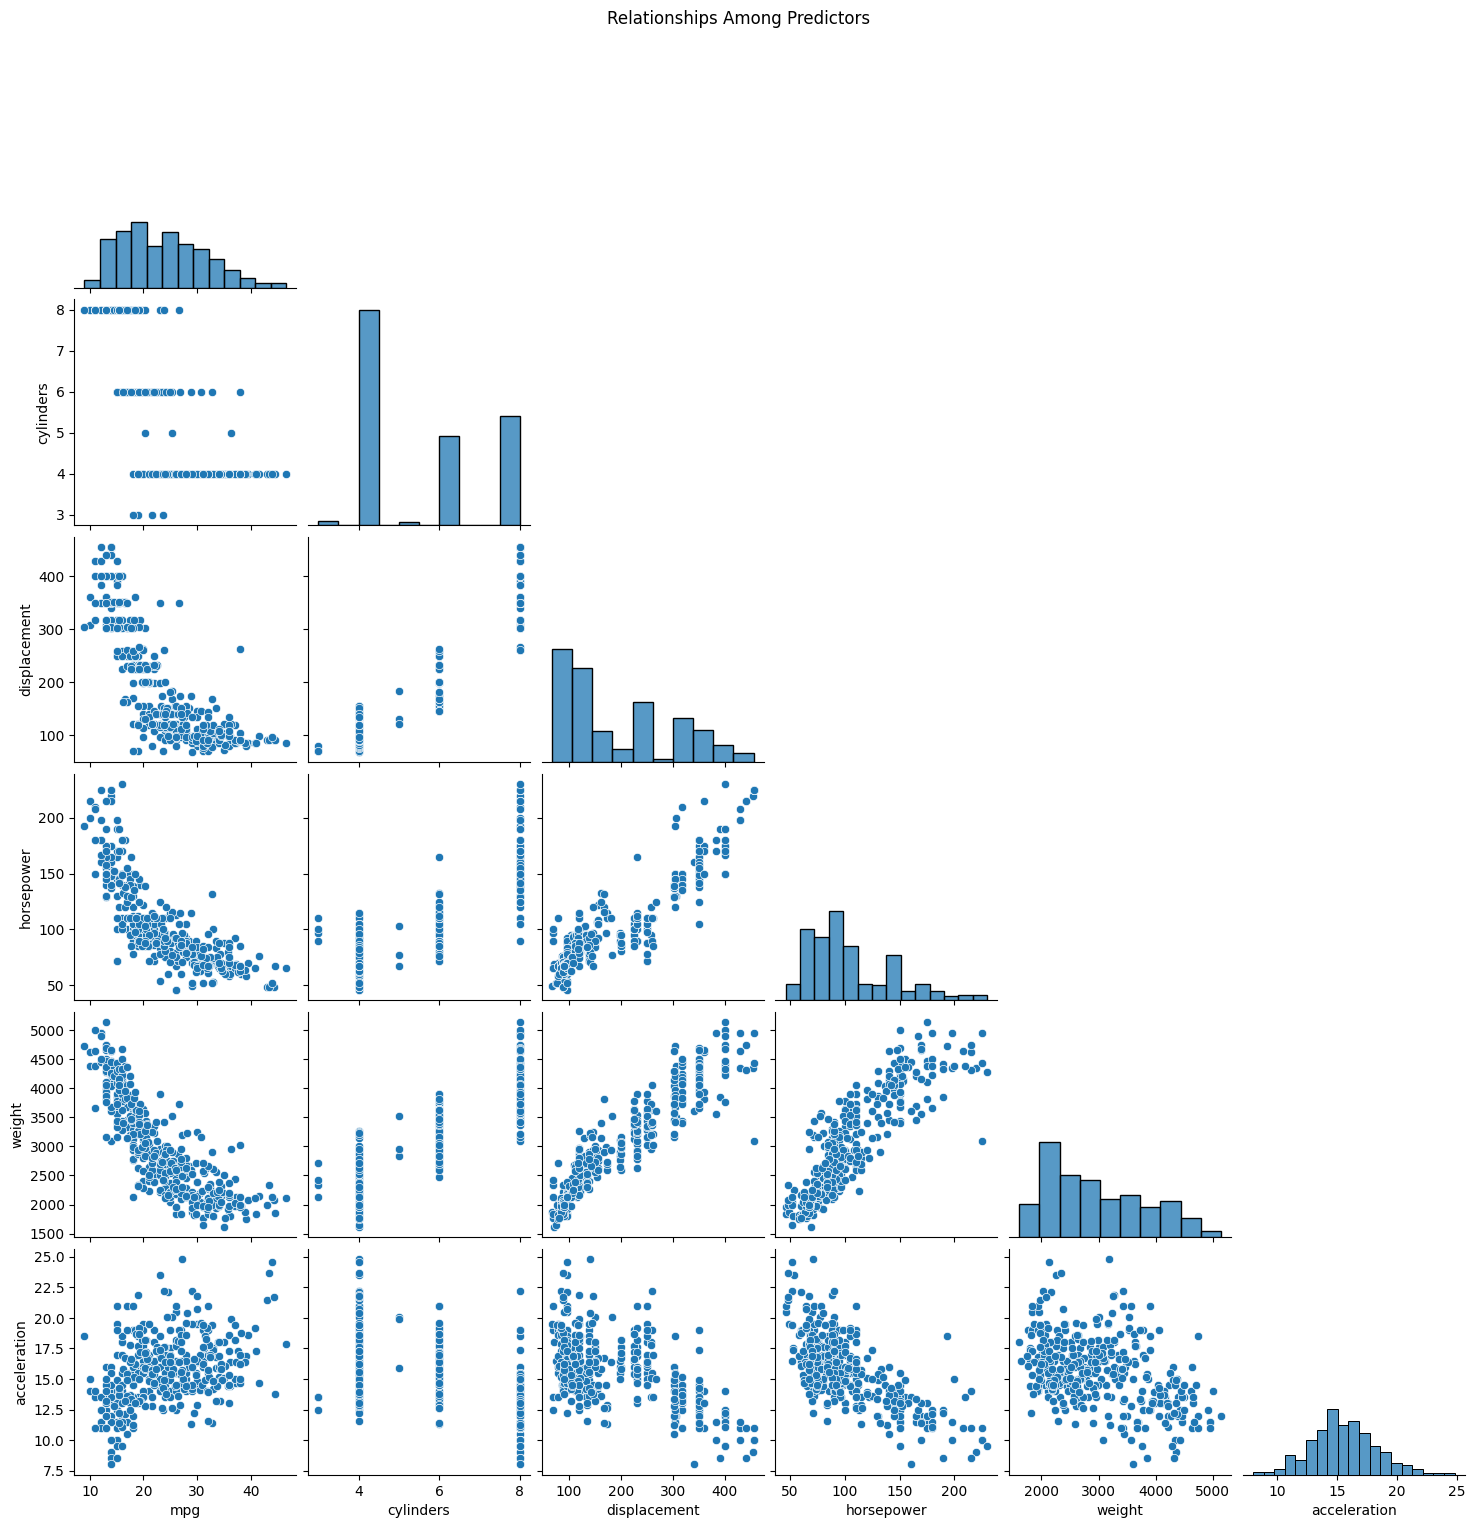

In [89]:
# (e)

import seaborn as sns
import matplotlib.pyplot as plt

# All quantitative predictors
predictors = ['mpg','cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

# Scatter plots and histograms
sns.pairplot(auto[predictors], corner=True)
plt.suptitle('Relationships Among Predictors', y=1.02)
plt.show()

Looking at `acceleration`, it has an inverse relationship with `horsepower` and `displacement`. Because `acceleration` is measured as the time it takes to reach 60 mph, the lower  the values the faster the vehicles. Thus, cars with higher horsepower reach target speeds in significantly less time.  

`weight` and `horsepower` has an apparent positive, slightly non-linear correlation, where heavier vehicles consistently require larger horsepower engines to operate.

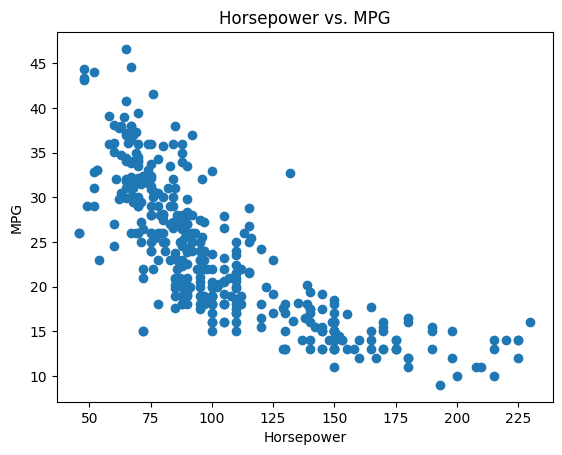

In [90]:
plt.scatter(auto["horsepower"], auto["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs. MPG")

plt.show()

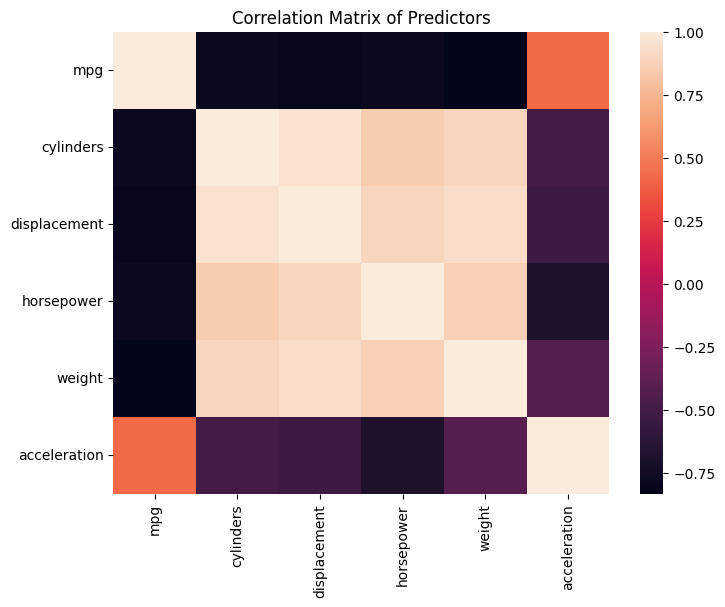

In [91]:
# Correlation matrix

plt.figure(figsize=(8, 6))
sns.heatmap(auto[predictors].corr())
plt.title('Correlation Matrix of Predictors')
plt.show()

Deep colored negative blocks, such as `horsepower` and `acceleration`) highlight inverse relationships where higher capacity directly reduces the other measure  

Cells with faded or neutral colors pinpoint predictors that have no clear linear relationship with one another.

(f)  

Yes, the plots strongly indicate that several variables are highly predictive of gas mileage (`mpg`). Vehicle `weight`, `displacement`, `horsepower`, and `cylinders` show more apparent negative relationships with `mpg`, meaning heavier and more powerful cars need significantly more fuel.


### Question 10

In [92]:
# (a)

boston = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/refs/heads/main/Dataset/Boston.csv")

In [93]:
# (b)

print(boston)

     Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0             1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1             2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2             3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3             4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4             5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   
..          ...      ...   ...    ...   ...    ...    ...   ...     ...  ...   
501         502  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1   
502         503  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1   
503         504  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1   
504         505  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1   
505         506  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1   

     tax  ptratio  lstat  medv  
0    2

Rows: 506  
Columns: 13  

Each row represents a specific suburb or census tract in the Boston area. Each column represents a distinct housing or neighborhood attribute, such as crime rates and land zoning.

In [94]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


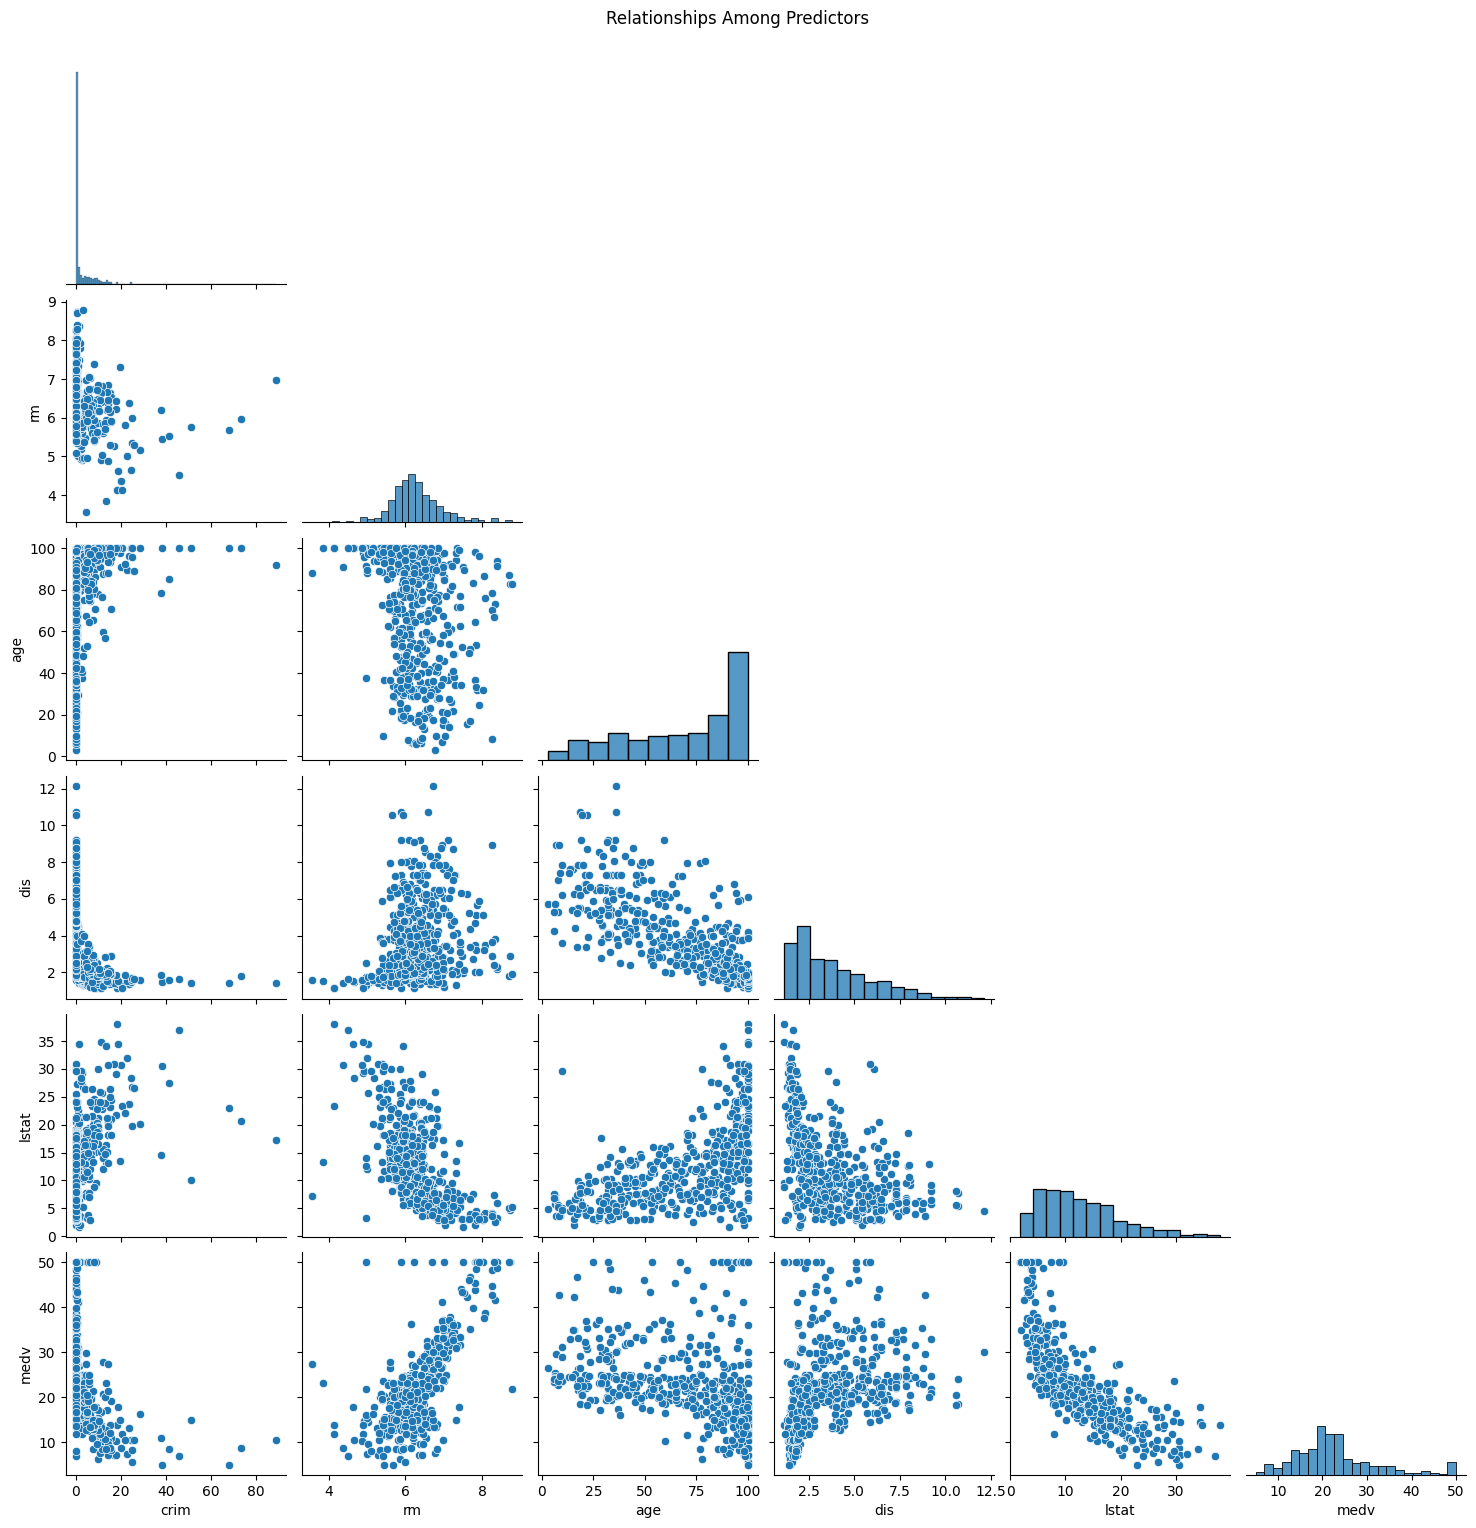

In [95]:
# (c)

# Some chosen quantitative predictors
predictors = ['crim', 'rm', 'age', 'dis', 'lstat', 'medv']

# Scatter plots and histograms
sns.pairplot(boston[predictors], corner=True)
plt.suptitle('Relationships Among Predictors', y=1.02)
plt.show()

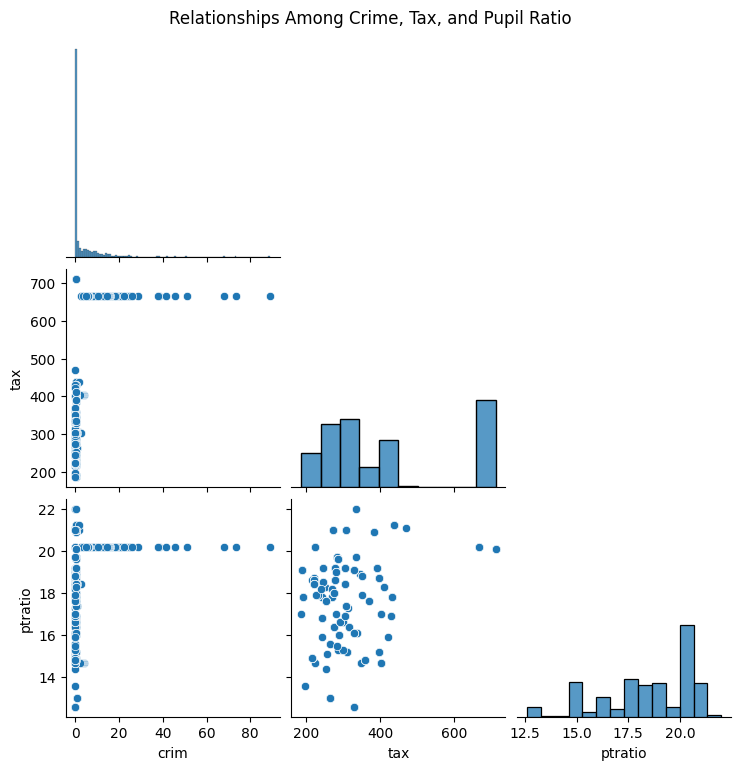

In [96]:
predictors2 = ['crim', 'tax', 'ptratio']

sns.pairplot(boston[predictors2], corner=True)
plt.suptitle('Relationships Among Crime, Tax, and Pupil Ratio', y=1.02)
plt.show()

Home value (`medv`) and lower-class populations (`lstat`) has a strong, negative non-linear relationship, and it flat lines near the baseline price floor.  

We can also see in crime rates (`crim`) it remains near zero across the majority of the other predictors, however it spikes exclusively in areas with low employment distance (`dis`), high proportion of older units (`age`), and low median home values (`medv`).  

(d)  

Yes, several predictors show strong associations with per capita crime rate (`crim`). Crime stays relatively flat at zero across most of the suburbs, however rates spike significangly in older urban areas located close to employment/city areas (`low dis`, `high age`), as well as in lower socioeconomic status (`lstat`) and high industrial zoning (`indus`) areas. We can interpret that big suburban houses far from downtown see almost no crime, while older, cheaper urban areas face most of it.


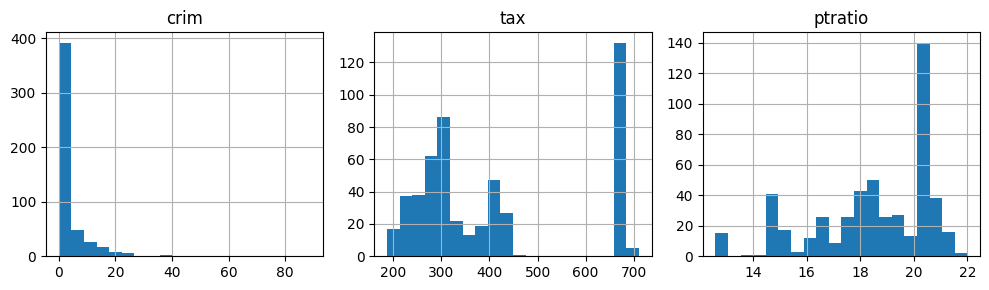

In [97]:
boston[['crim', 'tax', 'ptratio']].hist(bins=20, figsize=(10, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

(e)  

Yes, `crim`, `tax` and `ptratio` reveal that there are distinct suburbs that have particularly high crime rates. Tax rates show a large group of suburbs centered around the 200–400 range. While crime rates stay near zero for the vast majority of suburbs, a right tail stretches to nearly 90. Tax rates follow a little bit of a bimodal pattern across 187 to 711, with a high spike of over 130 around 650. Pupil-teacher ratios display a tighter range of roughly 13 to 22, with a sharp concentration of suburbs experiencing the highest classroom ratios around 20 to 21 students per teacher.

In [98]:
# (f)

boston['chas'].value_counts()

,count
chas,
0,471
1,35


35 suburbs are bound by the Charles River.

In [99]:
# (g)

boston['ptratio'].median()

19.05

 The median pupil-teacher ratio is 19.05.

In [100]:
# (h)

lowest_suburbs = boston[boston['medv'] == boston['medv'].min()]
print(lowest_suburbs)

     Unnamed: 0     crim   zn  indus  chas    nox     rm    age     dis  rad  \
398         399  38.3518  0.0   18.1     0  0.693  5.453  100.0  1.4896   24   
405         406  67.9208  0.0   18.1     0  0.693  5.683  100.0  1.4254   24   

     tax  ptratio  lstat  medv  
398  666     20.2  30.59   5.0  
405  666     20.2  22.98   5.0  


The suburbs with the lowest median value of owneroccupied homes are 398 and 405.

The suburbs with the lowest home values sit at the most disadvantaged extremes across nearly every predictor in the dataset. They are dense, older urban neighborhoods located right by major highway hubs with heavy industrial zoning, high pollution, and high property tax rates. Furthermore, they face severe socioeconomic strain, which is shown by extremely high crime rates, greater poverty levels (`lstat`), and crowded classroom ratios.

In [101]:
# (i)

print((boston['rm'] > 7).sum()) # More than 7 rooms
print((boston['rm'] > 8).sum()) # More than 8 rooms

64
13


There are 64 suburbs that average more than seven rooms per dwelling, and 13 suburbs that average more than eight rooms per dwelling.

Suburbs averaging more than eight rooms represent the wealthiest and more affluent communities in the dataset, with median home values that frequently reach the dataset maximum of $50,000. These suburbs show the lowest per capita crime rates, very low poverty percentages (lstat), and better pupil-teacher ratios than the regional average. Geographically, they are far from industrial buildings ('indus') and have more empty space with large homes.